In [20]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from numpy import cos,pi,sqrt,log10
from astropy.table import Table
from astropy.table import unique
import os
import ctadata
from astropy.io import ascii
from scipy import stats
from scipy.stats import chi2, poisson
from scipy.optimize import curve_fit, least_squares, nnls, brentq


In [2]:
data_folder = "./LST_data/"
DL3_folder = "/pnfs/cta.cscs.ch/lst/DL3/"
run_catalog=ascii.read(data_folder + 'LST_source_catalog.ecsv')

In [3]:
e_bins=np.logspace(np.log10(0.01), np.log10(10), 11)
e_mins=e_bins[:-1]
e_maxs=e_bins[1:]
e_means=np.sqrt(e_mins*e_maxs)
de=e_maxs-e_mins

th2_bins=np.linspace(0,0.16,34)
th2=(th2_bins[1:]+th2_bins[:-1])/2.

In [4]:
def find_and_process_files(runlist, gheff, 
                          ra_obj, dec_obj, bkg_subtraction_radius,
                          e_mins, e_maxs, e, th2_bins,
                          cts_s, cts_b, t_expo):
    counter = 0
    for ind in range(len(runlist)):
        r = runlist[ind]
        for i in range(len(run_catalog)):
            run = run_catalog[i]['Run ID']
            if run == r:
                date = run_catalog[i]['Date directory'].replace('-', '')
                vers = ctadata.list_dir(DL3_folder + date)
                for ver in vers:
                    if ver[0] == 'v':
                        tailcuts = ctadata.list_dir(DL3_folder + date + '/' + ver)
                        for tailcut in tailcuts:
                            nsbs = ctadata.list_dir(DL3_folder + date + '/' + ver + '/' + tailcut)
                            for nsb in nsbs:
                                versions = ctadata.list_dir(DL3_folder + date + '/' + ver + '/' + tailcut + '/' + nsb)
                                for version in versions:
                                    tags = ctadata.list_dir(DL3_folder + date + '/' + ver + '/' + tailcut + '/' + nsb + '/' + version + '/std')
                                    for tag in tags:
                                        src_dependences = ctadata.list_dir(DL3_folder + date + '/' + ver + '/' + tailcut + '/' + nsb + '/' + version + '/std/' + tag)
                                        for src_dep in src_dependences:
                                            point_or_full = ctadata.list_dir(DL3_folder + date + '/' + ver + '/' + tailcut + '/' + nsb + '/' + version + '/std/' + tag + '/' + src_dep)
                                            for p_f in point_or_full:
                                                wobbles = ctadata.list_dir(DL3_folder + date + '/' + ver + '/' + tailcut + '/' + nsb + '/' + version + '/std/' + tag + '/' + src_dep + '/' + p_f)
                                                for wob in wobbles:
                                                    gheffs = ctadata.list_dir(DL3_folder + date + '/' + ver + '/' + tailcut + '/' + nsb + '/' + version + '/std/' + tag + '/' + src_dep + '/' + p_f + '/' + wob)
                                                    for gh in gheffs:
                                                        if gheff in gh:
                                                            irfs = ctadata.list_dir(DL3_folder + date + '/' + ver + '/' + tailcut + '/' + nsb + '/' + version + '/std/' + tag + '/' + src_dep + '/' + p_f + '/' + wob + '/' + gh)
                                                            for irf in irfs:
                                                                files = ctadata.list_dir(DL3_folder + date + '/' + ver + '/' + tailcut + '/' + nsb + '/' + version + '/std/' + tag + '/' + src_dep + '/' + p_f + '/' + wob + '/' + gh + '/' + irf)
                                                                
                                                                if run < 10000:
                                                                    fname = 'dl3_LST-1.Run0' + str(run) + '.fits'
                                                                else:
                                                                    fname = 'dl3_LST-1.Run' + str(run) + '.fits'
                                                                
                                                                if fname in files:
                                                                    file_path = DL3_folder + date + '/' + ver + '/' + tailcut + '/' + nsb + '/' + version + '/std/' + tag + '/' + src_dep + '/' + p_f + '/' + wob + '/' + gh + '/' + irf + '/' + fname
                                                                    ctadata.fetch_and_save_file_or_dir(file_path)
                                                                    
                                                                    with fits.open(fname) as hdul:
                                                                        header = hdul[1].header
                                                                        dat = header['DATE-OBS']
                                                                        t_expo += header['LIVETIME']
                                                                        print(ind, date, fname, header['LIVETIME'])
                                                                        
                                                                        ra_pnt = header['RA_PNT']
                                                                        dec_pnt = header['DEC_PNT']
                                                                        dra = ra_obj - ra_pnt
                                                                        ddec = dec_obj - dec_pnt
                                                                        
                                                                        ra_bkg = ra_pnt - dra
                                                                        dec_bkg = dec_pnt - ddec
                                                                        coords_bkg = SkyCoord(ra_bkg, dec_bkg, unit='degree')
                                                                        coords_obj = SkyCoord(ra_obj, dec_obj, unit='degree')
                                                                        
                                                                        events = hdul['EVENTS'].data
                                                                        coords = SkyCoord(events['RA'], events['DEC'], unit='degree')
                                                                        
                                                                        seps = coords.separation(coords_obj).deg
                                                                        seps_b = coords.separation(coords_bkg).deg
                                                                        energies = events['ENERGY']
                                                                        
                                                                        #effarea_hdu = hdul['EFFECTIVE AREA'].data
                                                                        #effarea = effarea_hdu["EFFAREA"] * 100**2 # m2 to cm2
                                                                        #effareas_ebins_mean = np.sqrt(effarea_hdu["ENERG_LO"] * effarea_hdu["ENERG_HI"])
                                                                        
                                                                        for i in range(len(e)):
                                                                            m_s = (energies > e_mins[i]) * (energies < e_maxs[i]) * (seps < bkg_subtraction_radius)
                                                                            h_s = np.histogram(seps[m_s]**2, bins=th2_bins)
                                                                            
                                                                            m_b = (energies > e_mins[i]) * (energies < e_maxs[i]) * (seps_b < bkg_subtraction_radius)
                                                                            h_b = np.histogram(seps_b[m_b]**2, bins=th2_bins)
                                                                            
                                                                            cts_s[i] += h_s[0]
                                                                            cts_b[i] += h_b[0]
                                                                            # If using this remember to square the error after the fuction.
                                                                            #effarea_usable_ind = np.argmin(np.abs(e[i] * np.ones(effareas_ebins_mean.shape[0]) - effareas_ebins_mean))
                                                                            #cts_effarea_corr[i] += (h_s[0] - h_b[0]) / effarea[0][0][effarea_usable_ind]
                                                                            #cts_effarea_corr_err[i] += ((np.sqrt(h_s[0] + h_b[0])) / effarea[0][0][effarea_usable_ind]) ** 2
                                                                    
                                                                    os.remove(fname)
                                                                    counter += 1
                                                                    if counter >= countermax:
                                                                        return cts_s, cts_b, t_expo
    
    return cts_s, cts_b, t_expo

**CRAB spectrum, PSF model**

In [5]:
Name = "Crab"
runlist = np.load(data_folder + 'good_runs_' + Name + '_Zd_30.0.npy')
gheff='gheff0.9'
Zdcut=30

coords_obj=SkyCoord.from_name(Name)
ra_obj=coords_obj.icrs.ra.deg
dec_obj=coords_obj.icrs.dec.deg
ra_obj,dec_obj
cdec=cos(dec_obj*pi/180.)

In [6]:
countermax = 100
bkg_subtraction_radius = 0.4

cts_s = np.zeros((len(e_means), len(th2)))
cts_b = np.zeros((len(e_means), len(th2)))

t_expo = 0

cts_s, cts_b, t_expo = find_and_process_files(
    runlist=runlist,
    gheff=gheff,
    ra_obj=ra_obj,
    dec_obj=dec_obj,
    bkg_subtraction_radius=bkg_subtraction_radius,
    e_mins=e_mins,
    e_maxs=e_maxs,
    e=e_means,
    th2_bins=th2_bins,
    cts_s=cts_s,
    cts_b=cts_b,
    t_expo=t_expo,
)
print(f"Total exposure: {t_expo/3600}h")

0 20200913 dl3_LST-1.Run02692.fits 795.7776004104894
1 20201118 dl3_LST-1.Run02929.fits 1006.0123373972738
2 20201118 dl3_LST-1.Run02930.fits 1107.1882837177604
3 20201118 dl3_LST-1.Run02931.fits 1097.356265673436
4 20201118 dl3_LST-1.Run02932.fits 1096.1565143582543
5 20201118 dl3_LST-1.Run02933.fits 1109.3478662613109
6 20201118 dl3_LST-1.Run02934.fits 1109.300005536095
7 20201119 dl3_LST-1.Run02949.fits 1143.8056892959899
8 20201119 dl3_LST-1.Run02950.fits 1166.1911191647434
9 20201119 dl3_LST-1.Run02956.fits 1090.0646574511518
10 20201120 dl3_LST-1.Run02967.fits 1149.9214354727594
11 20201120 dl3_LST-1.Run02968.fits 1134.1610077612274
12 20201120 dl3_LST-1.Run02969.fits 1132.271922550845
13 20201120 dl3_LST-1.Run02970.fits 1129.2942528667702
14 20201120 dl3_LST-1.Run02971.fits 1137.1767259743376
15 20201120 dl3_LST-1.Run02972.fits 1131.1740466356277
16 20201120 dl3_LST-1.Run02973.fits 1131.0302748757006
17 20201120 dl3_LST-1.Run02974.fits 1137.8402315313788
18 20201120 dl3_LST-1.Ru

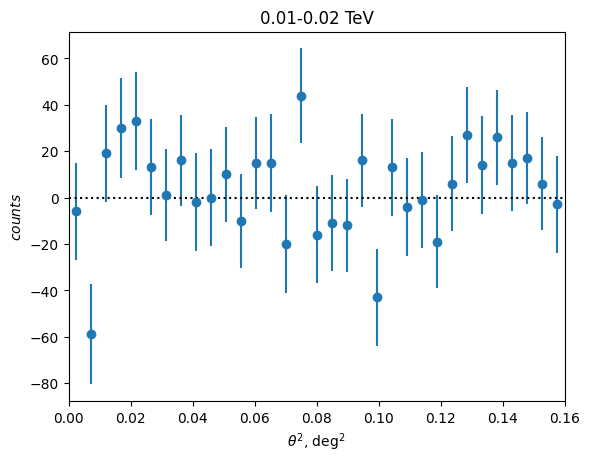

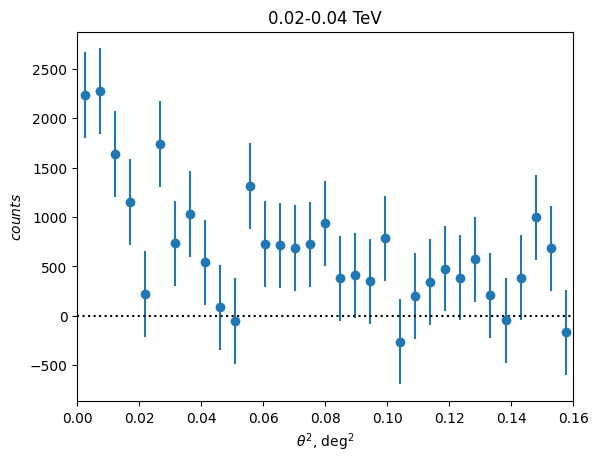

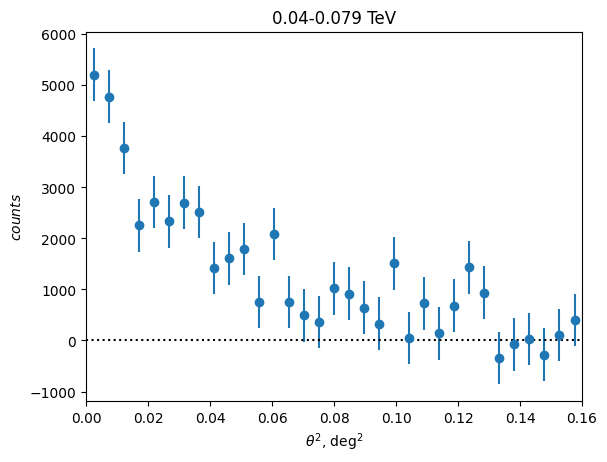

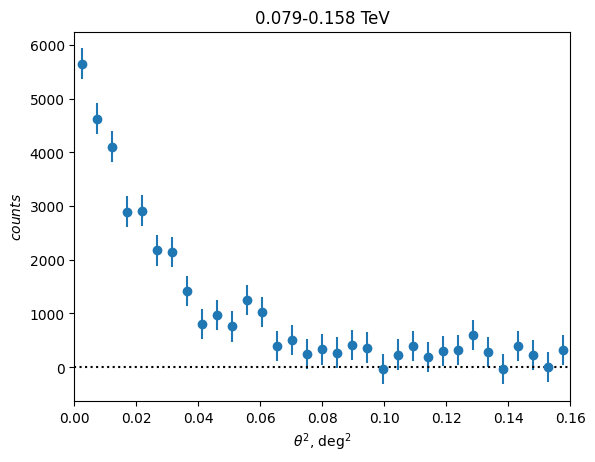

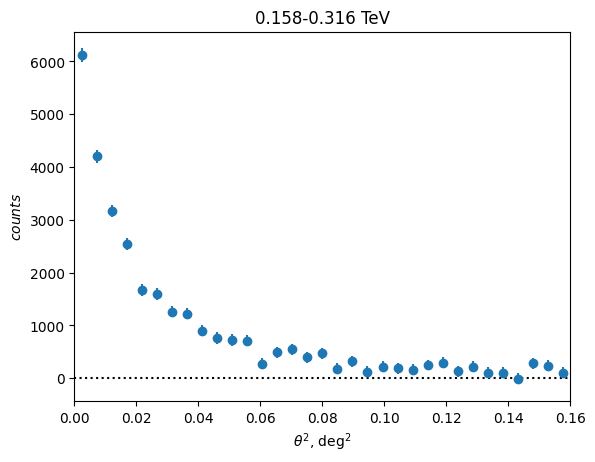

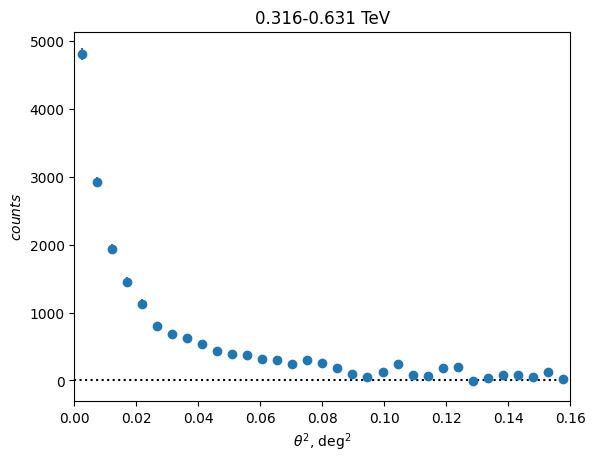

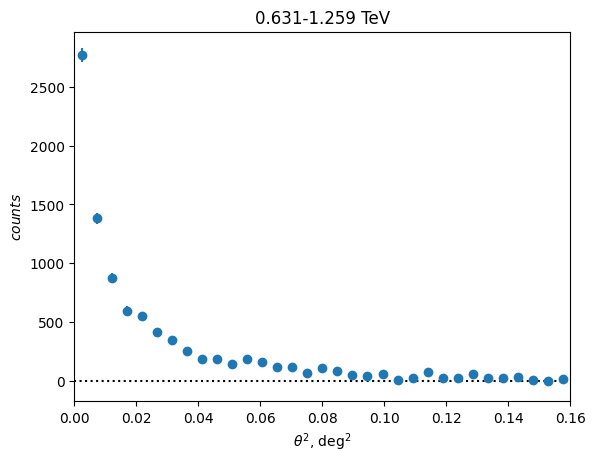

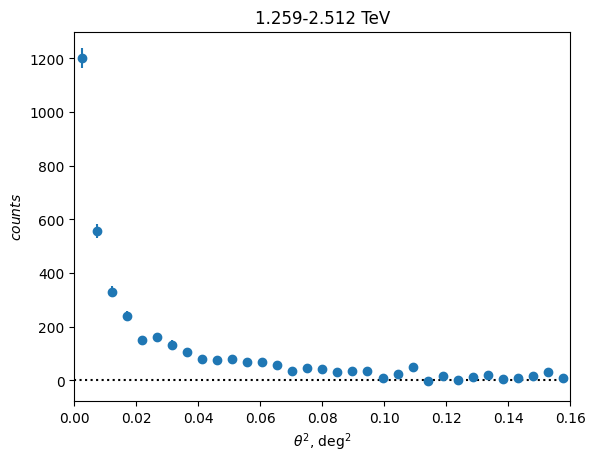

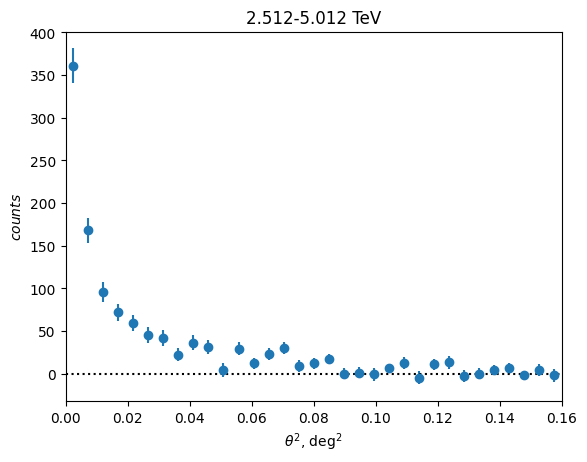

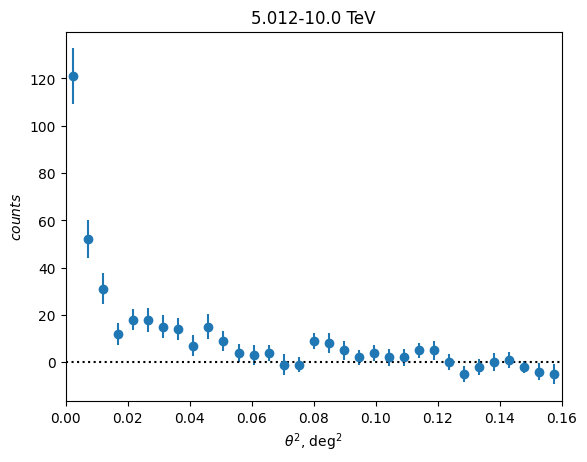

In [7]:
cts = cts_s - cts_b
cts_err = np.sqrt(cts_s + cts_b)

for i in range(cts.shape[0]):
    plt.figure()
    plt.errorbar(th2,cts[i], cts_err[i],fmt='o')
    plt.axhline(0,color='black',linestyle='dotted')
    plt.xlim(0,0.16)
    plt.title(str(round(e_mins[i],3))+'-'+str(round(e_maxs[i],3))+' TeV')
    plt.xlabel(r'$\theta^2$, deg$^2$')
    plt.ylabel(r'$counts$')
    plt.show()

In [8]:
def double_gaussian(th2, norm_tot, norm_t, sigma_c, sigma_t):
    gauss_c = norm_tot * np.exp(-th2 / (2 * sigma_c**2))
    gauss_t = norm_tot * norm_t * np.exp(-th2 / (2 * sigma_t**2))
    return gauss_c + gauss_t

In [9]:
init_guess = [5000.0, 0.1, 0.1, 0.2]

lower_bounds = [0.0, 0.0, 1e-6, 1e-6]
upper_bounds = [np.inf, np.inf, np.inf, np.inf]

fit_params = np.empty(len(e_means), dtype=object)
fit_errors = np.empty(len(e_means), dtype=object)

for i, (ct, ct_err) in enumerate(zip(cts, cts_err)):
    ct = np.asarray(ct, dtype=float)
    ct_err = np.asarray(ct_err, dtype=float)
    
    valid = (
        np.isfinite(th2)
        & np.isfinite(ct)
        & np.isfinite(ct_err)
        & (ct_err > 0)
    )

    try:
        popt, pcov = curve_fit(
            double_gaussian,
            th2[valid],
            ct[valid],
            sigma=ct_err[valid],
            p0=init_guess,
            bounds=(lower_bounds, upper_bounds),
            absolute_sigma=True,
            maxfev=100000,
        )
        
        fit_params[i] = popt
        fit_errors[i] = np.sqrt(np.maximum(np.diag(pcov), 0.0))
        
        norm_tot, norm_t, sigma_c, sigma_t = popt
        norm_tot_err, norm_t_err, sigma_c_err, sigma_t_err = np.sqrt(np.diag(pcov))

        print(rf"$E \in [{e_mins[i]}, {e_maxs[i]}]$:")
        print(rf"Core Gaussian: $\sigma = {sigma_c:.3f} \pm {sigma_c_err:.3f}$")
        print(rf"Tail Gaussian 2: $\sigma = {sigma_t:.3f} \pm {sigma_t_err:.3f}, Norm = {norm_t} \pm {norm_t_err}$")
        print("\n")
        
    except Exception as e:
        print(f"Fit failed for energy bin {i}: {e}")
        print("\n")

$E \in [0.01, 0.0199526231496888]$:
Core Gaussian: $\sigma = 0.087 \pm 10.042$
Tail Gaussian 2: $\sigma = -0.087 \pm 10.092, Norm = -0.9946948049340264 \pm 281.44711015827124$


$E \in [0.0199526231496888, 0.039810717055349734]$:
Core Gaussian: $\sigma = 0.080 \pm 0.028$
Tail Gaussian 2: $\sigma = 0.295 \pm 0.174, Norm = 0.3974460891968666 \pm 0.34844321304102965$


$E \in [0.039810717055349734, 0.07943282347242814]$:
Core Gaussian: $\sigma = 0.066 \pm 0.036$
Tail Gaussian 2: $\sigma = 0.162 \pm 0.021, Norm = 1.7376779616591915 \pm 1.357850270096813$


$E \in [0.07943282347242814, 0.15848931924611134]$:
Core Gaussian: $\sigma = 0.109 \pm 0.008$
Tail Gaussian 2: $\sigma = 307.039 \pm 245992741.207, Norm = 0.03336684787019696 \pm 0.07373132037920964$


$E \in [0.15848931924611134, 0.31622776601683794]$:
Core Gaussian: $\sigma = 0.073 \pm 0.004$
Tail Gaussian 2: $\sigma = 0.157 \pm 0.011, Norm = 0.33884771179951517 \pm 0.08930569500023264$


$E \in [0.31622776601683794, 0.630957344480193]

/tmp/ipykernel_50377/3938969378.py:6: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


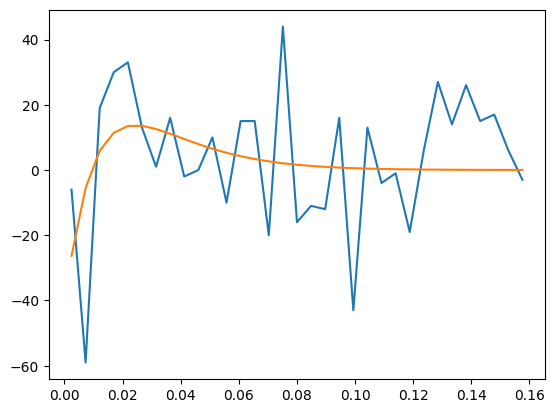

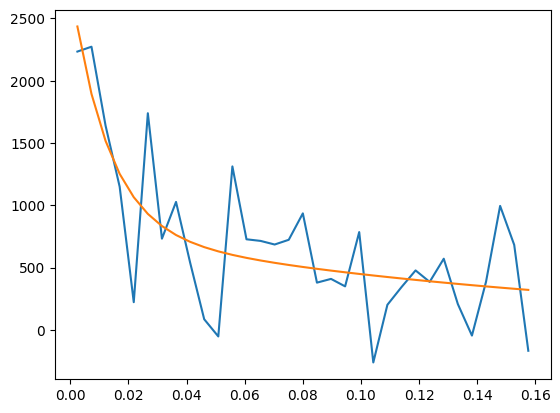

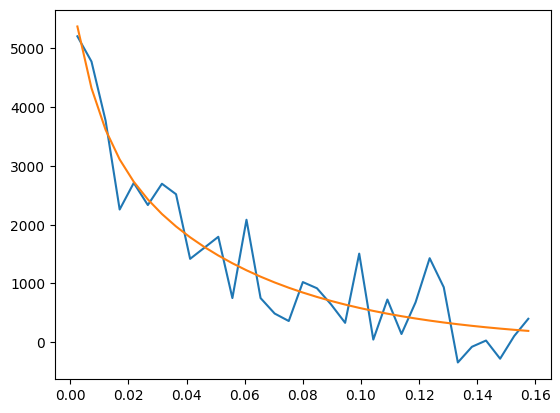

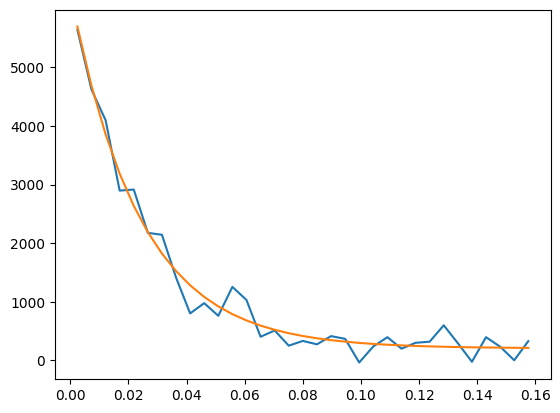

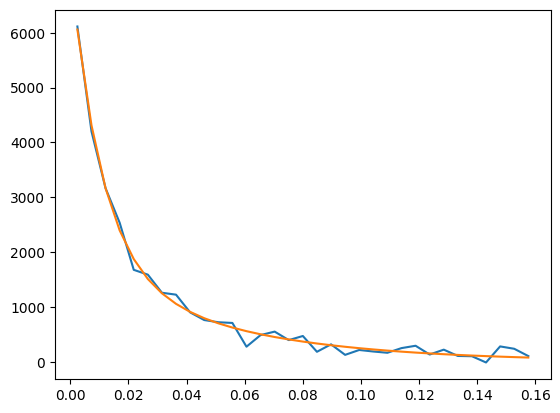

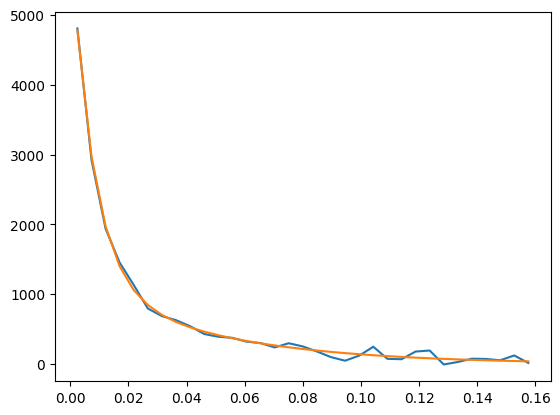

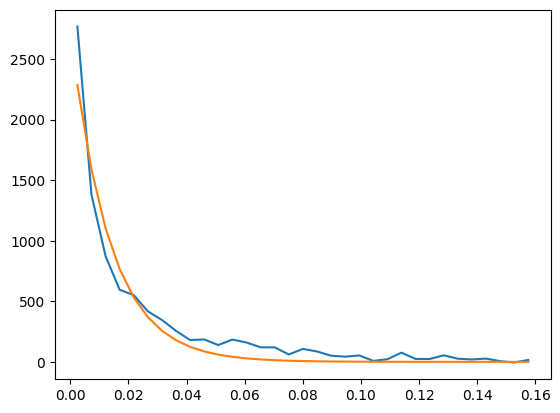

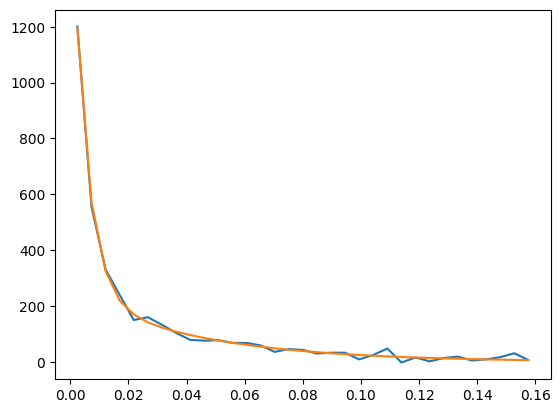

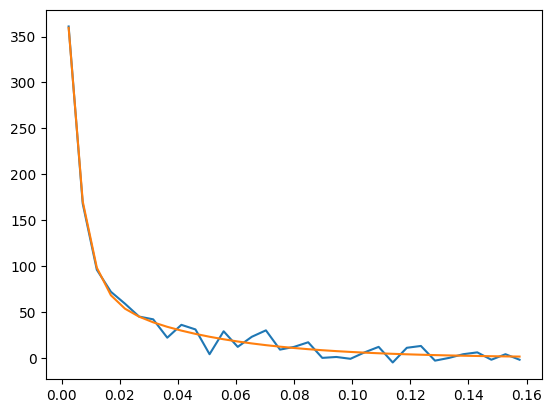

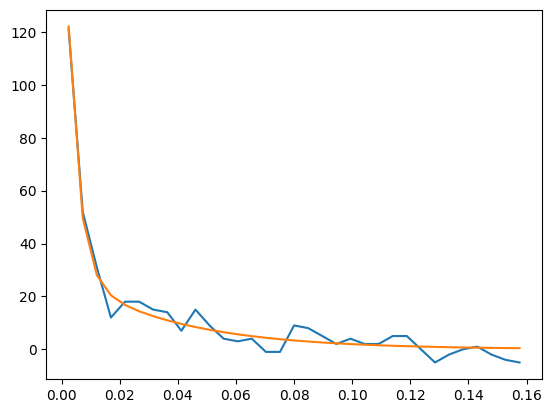

In [10]:
for i, (ct, ct_err) in enumerate(zip(cts, cts_err)):
    plt.figure()
    plt.plot(th2, ct)
    if fit_params[i] is None:
        plt.show()
        continue
    fit = double_gaussian(th2, *fit_params[i])
    plt.plot(th2, fit)
    plt.show()

In [11]:
np.save("../crab_fit", fit_params)

**Mrk 501 UL**

In [12]:
Name = "Mrk501"
runlist = np.load(data_folder + 'good_runs_' + Name + '_Zd_30.0.npy')
gheff='gheff0.9'
Zdcut=30

coords_obj=SkyCoord.from_name(Name)
ra_obj=coords_obj.icrs.ra.deg
dec_obj=coords_obj.icrs.dec.deg
ra_obj,dec_obj
cdec=cos(dec_obj*pi/180.)

In [13]:
countermax = 50
bkg_subtraction_radius = 0.4

cts_s = np.zeros((len(e_means), len(th2)))
cts_b = np.zeros((len(e_means), len(th2)))

t_expo = 0

cts_s, cts_b, t_expo = find_and_process_files(
    runlist=runlist,
    gheff=gheff,
    ra_obj=ra_obj,
    dec_obj=dec_obj,
    bkg_subtraction_radius=bkg_subtraction_radius,
    e_mins=e_mins,
    e_maxs=e_maxs,
    e=e_means,
    th2_bins=th2_bins,
    cts_s=cts_s,
    cts_b=cts_b,
    t_expo=t_expo,
)
print(f"Total exposure: {t_expo/3600}h")

0 20210317 dl3_LST-1.Run04139.fits 1130.0273713094493
1 20210317 dl3_LST-1.Run04140.fits 1155.6040742903724
2 20210320 dl3_LST-1.Run04191.fits 1090.8443539007542
3 20210320 dl3_LST-1.Run04192.fits 1057.6035122864566
4 20210320 dl3_LST-1.Run04193.fits 1011.8741674186106
5 20210320 dl3_LST-1.Run04194.fits 468.0308600181666
7 20210321 dl3_LST-1.Run04212.fits 851.6007298327497
8 20210321 dl3_LST-1.Run04213.fits 853.1299317712834
9 20210321 dl3_LST-1.Run04214.fits 845.836385717532
10 20210321 dl3_LST-1.Run04215.fits 852.2641518893802
11 20210417 dl3_LST-1.Run04473.fits 572.5225141427318
12 20210417 dl3_LST-1.Run04474.fits 1132.3215512024444
13 20210417 dl3_LST-1.Run04475.fits 1137.6344790185653
14 20210417 dl3_LST-1.Run04476.fits 571.5857753250073
15 20210418 dl3_LST-1.Run04483.fits 859.8120407428157
16 20210418 dl3_LST-1.Run04484.fits 1138.5015524738958
17 20210419 dl3_LST-1.Run04496.fits 1021.9748575572272
18 20210419 dl3_LST-1.Run04497.fits 1022.8591745170011
19 20210419 dl3_LST-1.Run044

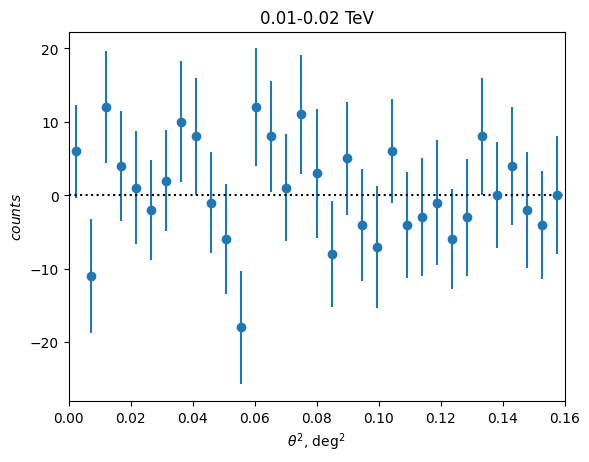

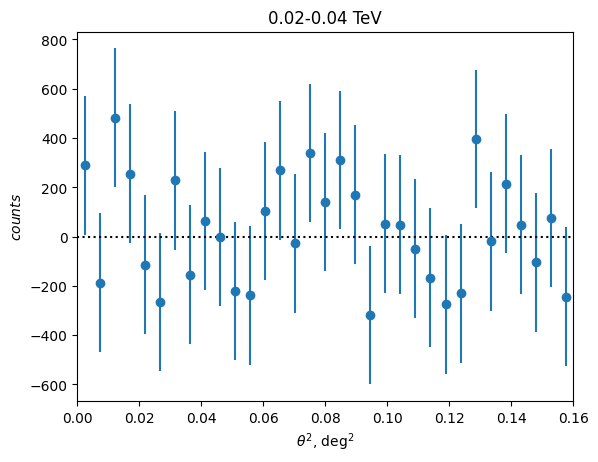

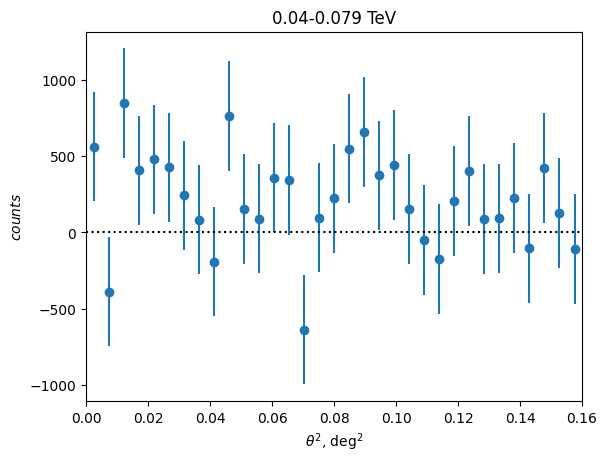

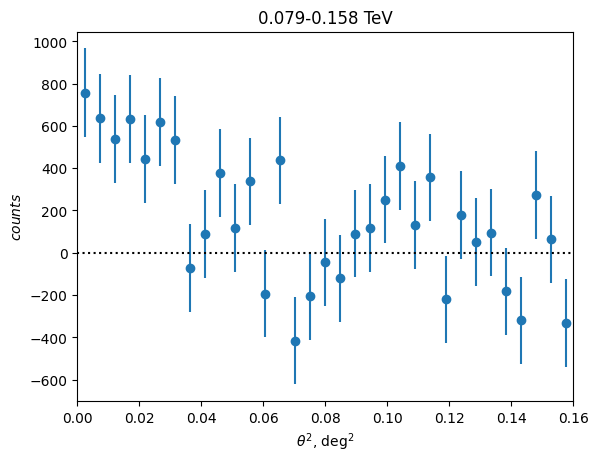

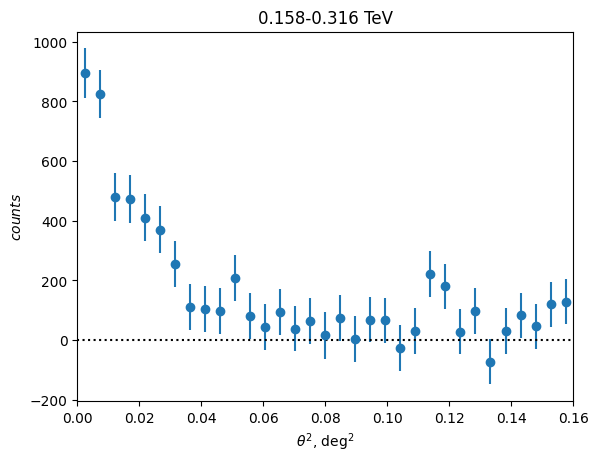

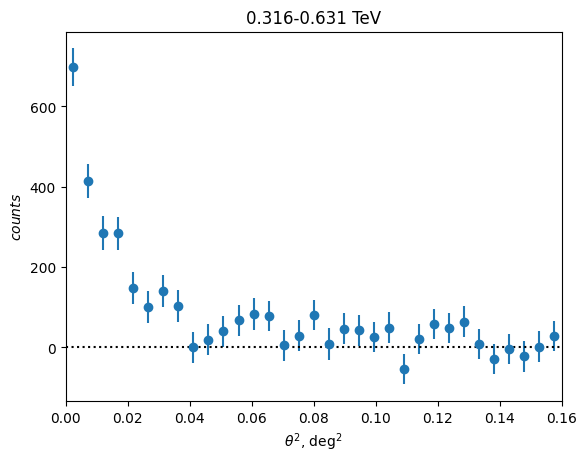

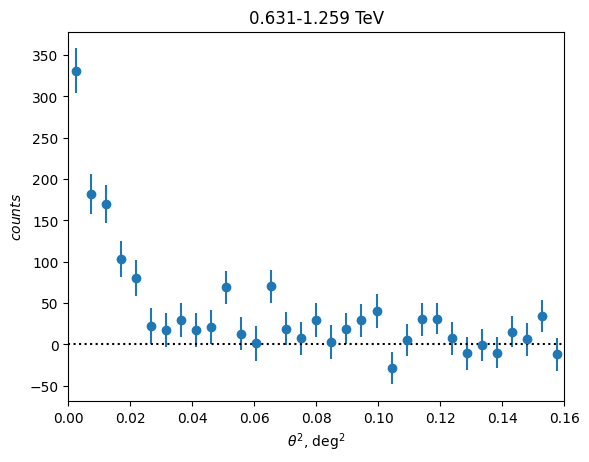

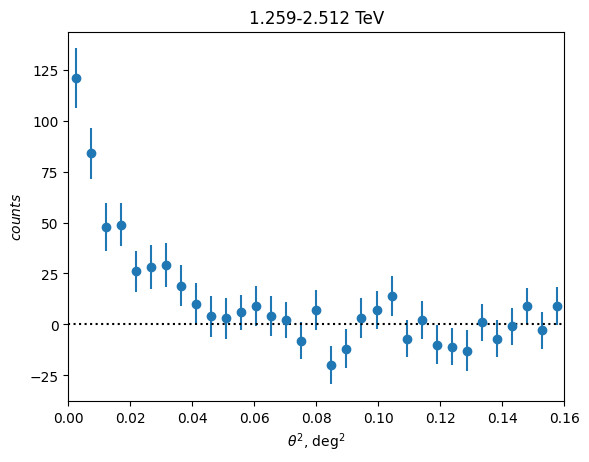

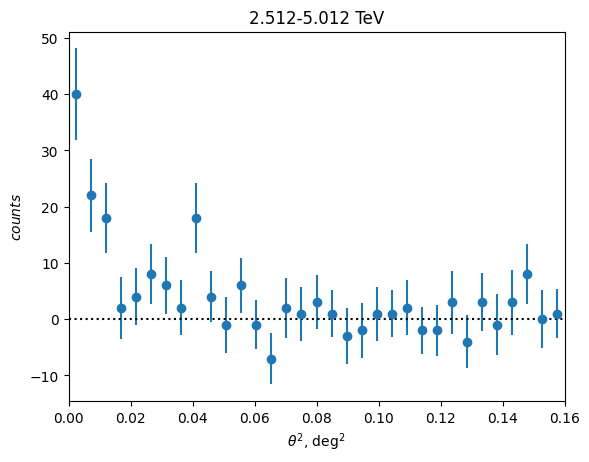

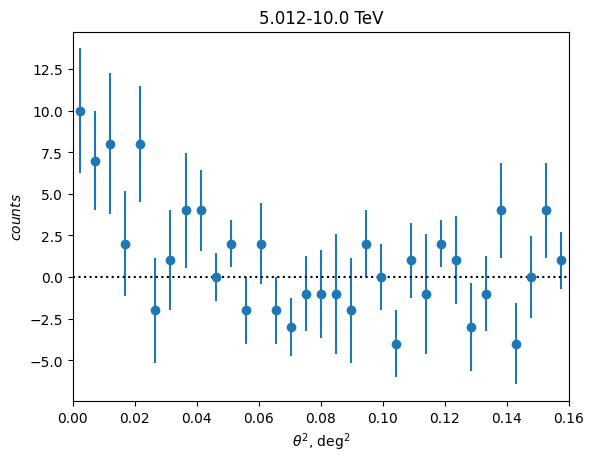

In [14]:
cts = cts_s - cts_b
cts_err = np.sqrt(cts_s + cts_b)

for i in range(cts.shape[0]):
    plt.figure()
    plt.errorbar(th2,cts[i], cts_err[i],fmt='o')
    plt.axhline(0,color='black',linestyle='dotted')
    plt.xlim(0,0.16)
    plt.title(str(round(e_mins[i],3))+'-'+str(round(e_maxs[i],3))+' TeV')
    plt.xlabel(r'$\theta^2$, deg$^2$')
    plt.ylabel(r'$counts$')
    plt.show()

In [15]:
sigmas_ext = np.linspace(0.05, 0.5, 10)

In [22]:
def chi2(y, model, error):
    return np.sum(((y - model) / error) ** 2)

def fit_point_amplitude(y, error, point_template):
    #Weighted least-squares point-source amplitude, constrained >= 0.
    # it minimizes the chi2 np.sum(((y - amplitude * point_template) / error)**2)
    weights = 1.0 / error**2
    amplitude = np.sum(weights * point_template * y)
    amplitude /= np.sum(weights * point_template**2)
    return max(amplitude, 0.0)
    
def psf(th2, psf_params):
    return double_gaussian(th2, *psf_params)

def ext_convoluted(th2, sigma_ext, psf_params):
    ampl_tot, norm_t, sigma_c, sigma_t = psf_params
    
    sigma_c_conv = np.sqrt(sigma_c**2 + sigma_ext**2)
    sigma_t_conv = np.sqrt(sigma_t**2 + sigma_ext**2)
    c1 = sigma_c**2/sigma_c_conv**2
    c2 = norm_t*sigma_t**2/sigma_t_conv**2
    gauss_c_conv = c1 * np.exp(-th2 / (2 * sigma_c_conv**2))
    gauss_t_conv = c2 * np.exp(-th2 / (2 * sigma_t_conv**2))
    return gauss_c_conv + gauss_t_conv

In [32]:
def calculate_UL(
    cts,
    cts_err,
    th2,
    e,
    psf_fit_params,
    sigmas_ext,
    delta_chi2=2.71,
):
    cts = np.asarray(cts, dtype=float)
    cts_err = np.asarray(cts_err, dtype=float)
    th2 = np.asarray(th2, dtype=float)
    e = np.asarray(e, dtype=float)
    sigmas_ext = np.asarray(sigmas_ext, dtype=float)

    flux_ratios = np.zeros((len(sigmas_ext), len(e)))

    for i, (y, yerr) in enumerate(zip(cts, cts_err)):
        psf_params = psf_fit_params[i]
        
        # Point-source PSF template normalized
        psf_template = psf(th2, psf_params)
        psf_template /= np.sum(psf_template)

        # Point-source-only fit
        point_amp = fit_point_amplitude(y, yerr, psf_template)
        point_model = point_amp * psf_template
        chi2_point = chi2(y, point_model, yerr)

        for k, sigma_ext in enumerate(sigmas_ext):
            # Extended-source template: PSF convolved with a Gaussian extension
            ext_template = ext_convoluted(th2, sigma_ext, psf_params)
            ext_template /= np.sum(ext_template)

            # Simultaneous fit of point and extended amplitudes.
            design_matrix = np.column_stack(
                [psf_template, ext_template]
            )

            weighted_matrix = design_matrix / yerr[:, None]
            weighted_data = y / yerr

            # Non-negative least square - minimizes chi2 of the source+ext model
            amplitudes, _ = nnls(weighted_matrix, weighted_data)
            point_amp_best, ext_amp_best = amplitudes

            best_model = (
                point_amp_best * psf_template
                + ext_amp_best * ext_template
            )

            chi2_min = chi2(y, best_model, yerr)
            target = chi2_min + delta_chi2

            # Profile chi-square:
            # Fix the extended amplitude and refit the point amplitude.
            def profile_chi2(ext_amp):
                residual_after_ext = y - ext_amp * ext_template
                
                point_amp = fit_point_amplitude(
                    residual_after_ext,
                    yerr,
                    psf_template,
                )
                point_amp = max(point_amp, 0.0)

                model = (
                    point_amp * psf_template
                    + ext_amp * ext_template
                )

                return chi2(y, model, yerr)

            # Find an upper bracket for the root.
            lower = ext_amp_best
            upper = max(2.0 * lower, 1.0)

            for _ in range(100):
                if profile_chi2(upper) >= target:
                    break
                upper *= 2.0
            else:
                raise RuntimeError(
                    "Could not bracket the extended-source upper limit."
                )

            # Solve profile_chi2(ext_amp) = chi2_min + delta_chi2.
            ext_amp_ul = brentq(
                lambda a: profile_chi2(a) - target,
                lower,
                upper,
            )

            # The templates are normalized to unit sum, so amplitudes are
            # directly equivalent to total model counts.
            total_best_counts = point_amp_best + ext_amp_best
            flux_ratios[k, i] = ext_amp_ul / np.maximum(total_best_counts, 1)

    return flux_ratios


In [33]:
flux_ratios = calculate_UL(
    cts,
    cts_err,
    th2,
    e_means,
    fit_params,
    sigmas_ext,
    delta_chi2=2.71,
)

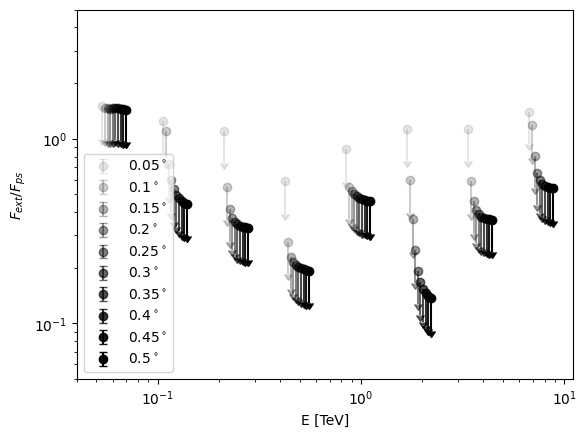

In [35]:
for i, flux_ratio in enumerate(flux_ratios):
    plt.errorbar(e_means*(0.95*1.03**i), flux_ratio,flux_ratio/3, alpha=0.1+0.1*i, uplims=True, linestyle='none',marker='o', label=str(round(sigmas_ext[i],3))+r'$^\circ$',color='black')
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.xlabel("E [TeV]")
plt.xlim(0.04,11)
plt.ylim(0.05, 5)
plt.legend()

In [ ]:
if Name == "Mrk421":
    z = 0.03
else:
    z = 0.033
B0 = np.array([5, 10, 20, 40])*10**(-15) # G
lambda_b = 10 # kpc
E_mat = e[:, np.newaxis] # column
B0_mat = B0[np.newaxis, :] # row

E_prime = np.sqrt(E_mat/0.33)*20
delta = 5*10**(-7)*(20/E_prime)**(3/2)*(B0/10**(-18))*(lambda_b)**(1/2)
#delta = 3*10**(-6)*(B0/10**(-18))*(E_prime/20)**(-2)
D_gamma = 40*20/E_prime
tau = 130/D_gamma

#theta_theor = D_gamma*delta/130
#theta_theor = delta/tau
theta_theor = 0.07*(1+z)**(-1/2)*(tau/10)**(-1)*(E_mat/0.1)**(-3/4)*(B0/10**(-14))*(lambda_b)**(1/2)


plt.plot(np.log10(E_mat), theta_theor[:, 0], 'white', linewidth=2, label=f"B0 = {B0_mat[0,0]:.0e} G")
plt.plot(np.log10(E_mat), theta_theor[:, 1], 'white', linewidth=2, linestyle='--', label=f"B0 = {B0_mat[0,1]:.0e} G")
plt.plot(np.log10(E_mat), theta_theor[:, 2], 'white', linewidth=2, linestyle=':', label=f"B0 = {B0_mat[0,2]:.0e} G")
plt.plot(np.log10(E_mat), theta_theor[:, 3], 'white', linewidth=2, linestyle='-.', label=f"B0 = {B0_mat[0,3]:.0e} G")


plt.xlabel("log(E/TeV)")
plt.ylabel("θ, deg")
plt.legend()
plt.title(f"{name}")

plt.imshow(np.log10(flux_ratios), extent=[np.log10(e[0]), np.log10(e[-1]), sigmas_ext[0], sigmas_ext[-1]], aspect='auto', origin='lower')
plt.colorbar(label=r"$log(F_{ext}/F_{ps})$")
#plt.savefig(f'./images/UL_{name}_DC_COMPLETE.png', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
def extr_data_from_csv(filepath):
    tot_datapoints = 10
    data = np.genfromtxt(filepath, delimiter=",", skip_header=1)

    if data.size == 0:
        return np.zeros(tot_datapoints)

    if data.ndim == 1:
        values = data
    else:
        values = data[:, 1] if data.shape[1] > 1 else data[:, 0]

    if len(values) < tot_datapoints:
        values = np.append(values, np.zeros(tot_datapoints - len(values)))

    return values

In [ ]:
ext_sim_flux = extr_data_from_csv("ext_sim_flux_data/ext_sim_flux.csv")
ext_sim_flux_up = extr_data_from_csv("ext_sim_flux_data/ext_sim_flux_errup.csv")
ext_sim_flux_down = extr_data_from_csv("ext_sim_flux_data/ext_sim_flux_errdown.csv")

In [ ]:
from scipy.interpolate import RegularGridInterpolator
linestyles = ["-", "--", ":", "-."]
starting_relevancy = [10**(-1), 10**(-0.75), 10**(-0.5), 10**(-0.25)]
for i, col_idx in enumerate(range(len(B0))):
    logE = np.log10(E_mat[:, 0])
    theta_curve = theta_theor[:, col_idx]
    
    logE_grid = np.log10(E_mat[:, 0])
    sigma_grid = sigmas_ext
    
    interpolator = RegularGridInterpolator((sigma_grid, logE_grid), 
                                           np.log10(flux_ratios), 
                                           bounds_error=False, 
                                           fill_value=None)
    
    points = np.column_stack([theta_curve, logE])
    flux_ratios_on_curve = 10**interpolator(points)
    print(flux_ratios_on_curve)

    if i==0:
        index_in = 3
        index_fin_rel = 4
    if i==1:
        index_in = 4
        index_fin_rel = 3
    if i==2:
        index_in = 5
        index_fin_rel = 2
    if i==3:
        index_in = 6
        index_fin_rel = 1
    plt.plot(E_mat[index_in:-index_fin_rel, 0], flux_ratios_on_curve[index_in:-index_fin_rel], color="black", alpha=1-0.25*i, linestyle=linestyles[i])
    plt.errorbar(E_mat[index_in:-index_fin_rel, 0], flux_ratios_on_curve[index_in:-index_fin_rel],np.abs(flux_ratios_on_curve[index_in:-index_fin_rel]/3), alpha=1-0.25*i, uplims=True, linestyle='none',marker='o', label=f"B0 = {B0[i]:.0e} G",color='black')
plt.plot(E_mat[:, 0], ext_sim_flux, color="blue")
plt.fill_between(E_mat[:, 0], ext_sim_flux_down, ext_sim_flux_up, color='blue', alpha=0.3)
plt.ylim([0.005, 5])
plt.xlim([0.05, 5])
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$E$, TeV")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.legend()
plt.title(f"{name}")
plt.savefig(f'./images/UL_{Name}_LST_SIM_FINAL.png', dpi=600, bbox_inches='tight')

In [ ]:
t_expo/60/60